<a href="https://colab.research.google.com/github/harshithakathir28-wq/DL_EX5/blob/main/DL_EX5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -q datasets

import numpy as np
import tensorflow as tf
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print("Name: Harshitha")
print("Roll No: 24BAD034")

dataset = load_dataset("Trelis/tiny-shakespeare")

print("Dataset:")
print(dataset)

print("Available Columns:")
print(dataset["train"].column_names)

column_name = dataset["train"].column_names[0]

text = dataset["train"][column_name][0].lower()

print("Text Sample:")
print(text[:500])

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text])

total_words = len(tokenizer.word_index) + 1

words = text.split()

sequences = []

for i in range(1, len(words)):
    sequence = " ".join(words[:i])
    token_list = tokenizer.texts_to_sequences([sequence])[0]
    sequences.append(token_list[-10:])

max_sequence_length = max(len(seq) for seq in sequences)

input_sequences = pad_sequences(
    sequences,
    maxlen=max_sequence_length,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Vocabulary Size:", total_words)
print("Total Sequences:", len(input_sequences))
print("Sequence Length:", max_sequence_length)
print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)

Name: Harshitha
Roll No: 24BAD034
Dataset:
DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})
Available Columns:
['Text']
Text Sample:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor
Vocabulary Size: 260
Total Sequences: 553
Sequence Length: 10
Training Data Shape: (442, 9)
Validation Data Shape: (111, 9)


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

print("Name: Harshitha")
print("Roll No: 24BAD034")

model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=64,
        input_length=X_train.shape[1]
    ),
    SimpleRNN(128),
    Dense(total_words, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Name: Harshitha
Roll No: 24BAD034


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.1923 - loss: 4.3551 - val_accuracy: 0.0631 - val_loss: 5.6700
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2738 - loss: 4.1805 - val_accuracy: 0.0541 - val_loss: 5.6591
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2941 - loss: 3.9951 - val_accuracy: 0.0631 - val_loss: 5.7196
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3733 - loss: 3.8079 - val_accuracy: 0.0721 - val_loss: 5.7021
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3982 - loss: 3.6254 - val_accuracy: 0.0811 - val_loss: 5.7332
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4480 - loss: 3.4312 - val_accuracy: 0.0631 - val_loss: 5.7481
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5249 - loss: 3.2450 - val_accuracy: 0.0721 - val_loss: 5.8408
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5475 - loss: 3.0594 - val_accuracy: 0.0721 - val_loss: 5.8617


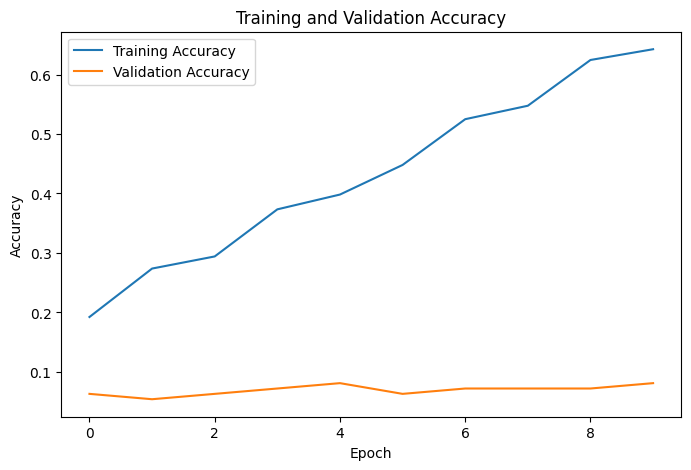

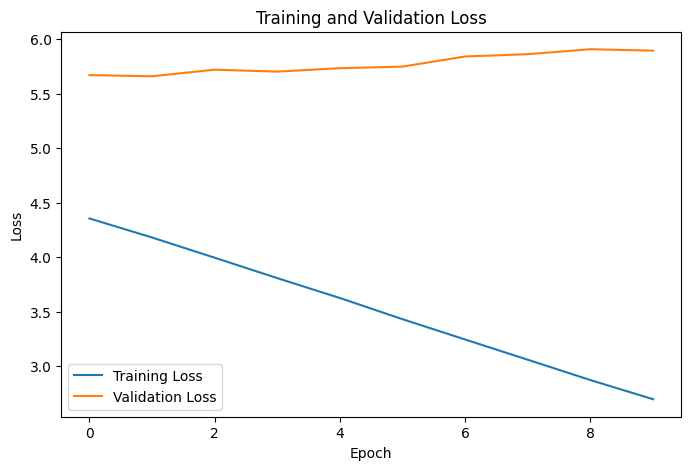

In [10]:
import matplotlib.pyplot as plt

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

print("Final Training Accuracy:", history.history["accuracy"][-1])
print("Final Validation Accuracy:", history.history["val_accuracy"][-1])
print("Final Training Loss:", history.history["loss"][-1])
print("Final Validation Loss:", history.history["val_loss"][-1])

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_text(seed_text, next_words):
    result = seed_text.lower()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result])[0]
        token_list = token_list[-X_train.shape[1]:]
        token_list = pad_sequences(
            [token_list],
            maxlen=X_train.shape[1],
            padding="pre"
        )

        predicted = model.predict(token_list, verbose=0)
        predicted_word_index = np.argmax(predicted, axis=1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_word_index:
                output_word = word
                break

        result += " " + output_word

    return result

print("Name: Harshitha")
print("Roll No: 24BAD034")

seed1 = "shall i compare thee"
seed2 = "to be or not"
seed3 = "what is the"

print("\nGenerated Text 1:")
print(generate_text(seed1, 15))

print("\nGenerated Text 2:")
print(generate_text(seed2, 15))

print("\nGenerated Text 3:")
print(generate_text(seed3, 15))

Name: Harshitha
Roll No: 24BAD034

Generated Text 1:
shall i compare thee he he he he he he hear which faults particularise particularise particularise well particularise but

Generated Text 2:
to be or not citizen he he we citizen first citizen we he undone enough would undone say be

Generated Text 3:
what is the he he he he he he citizen the not particularise particularise particularise well enough be
